# RAG

## 一、RAG流程

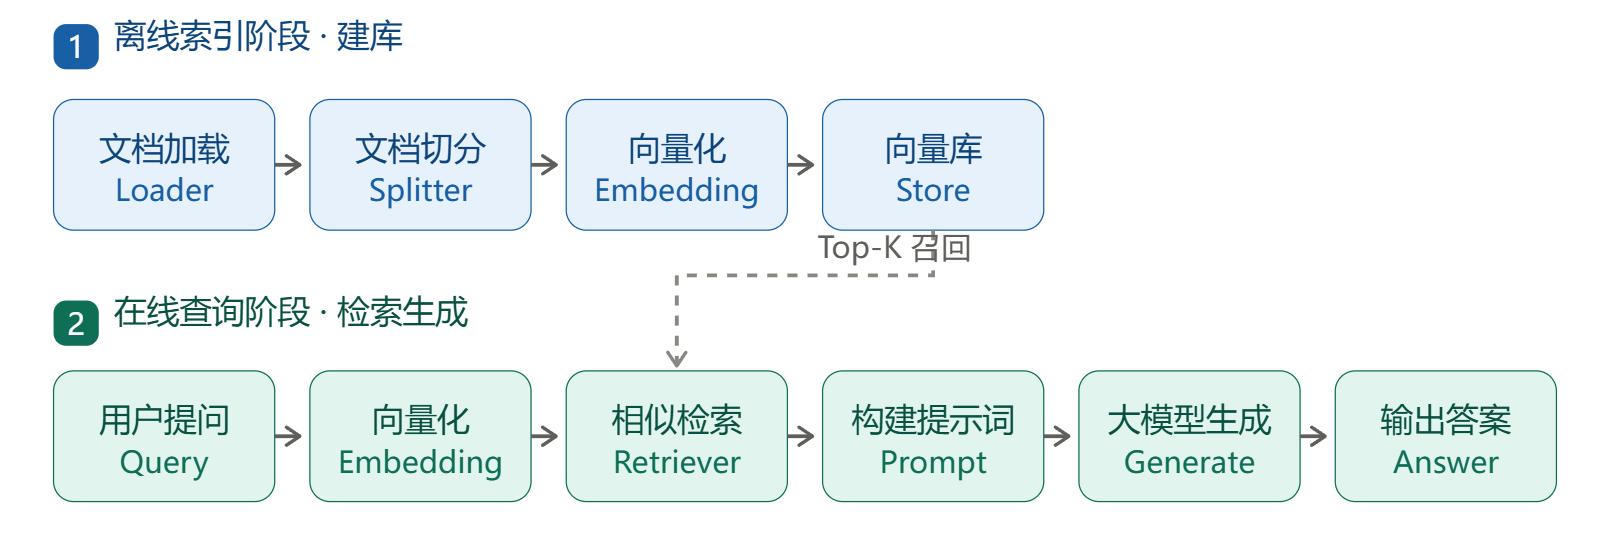

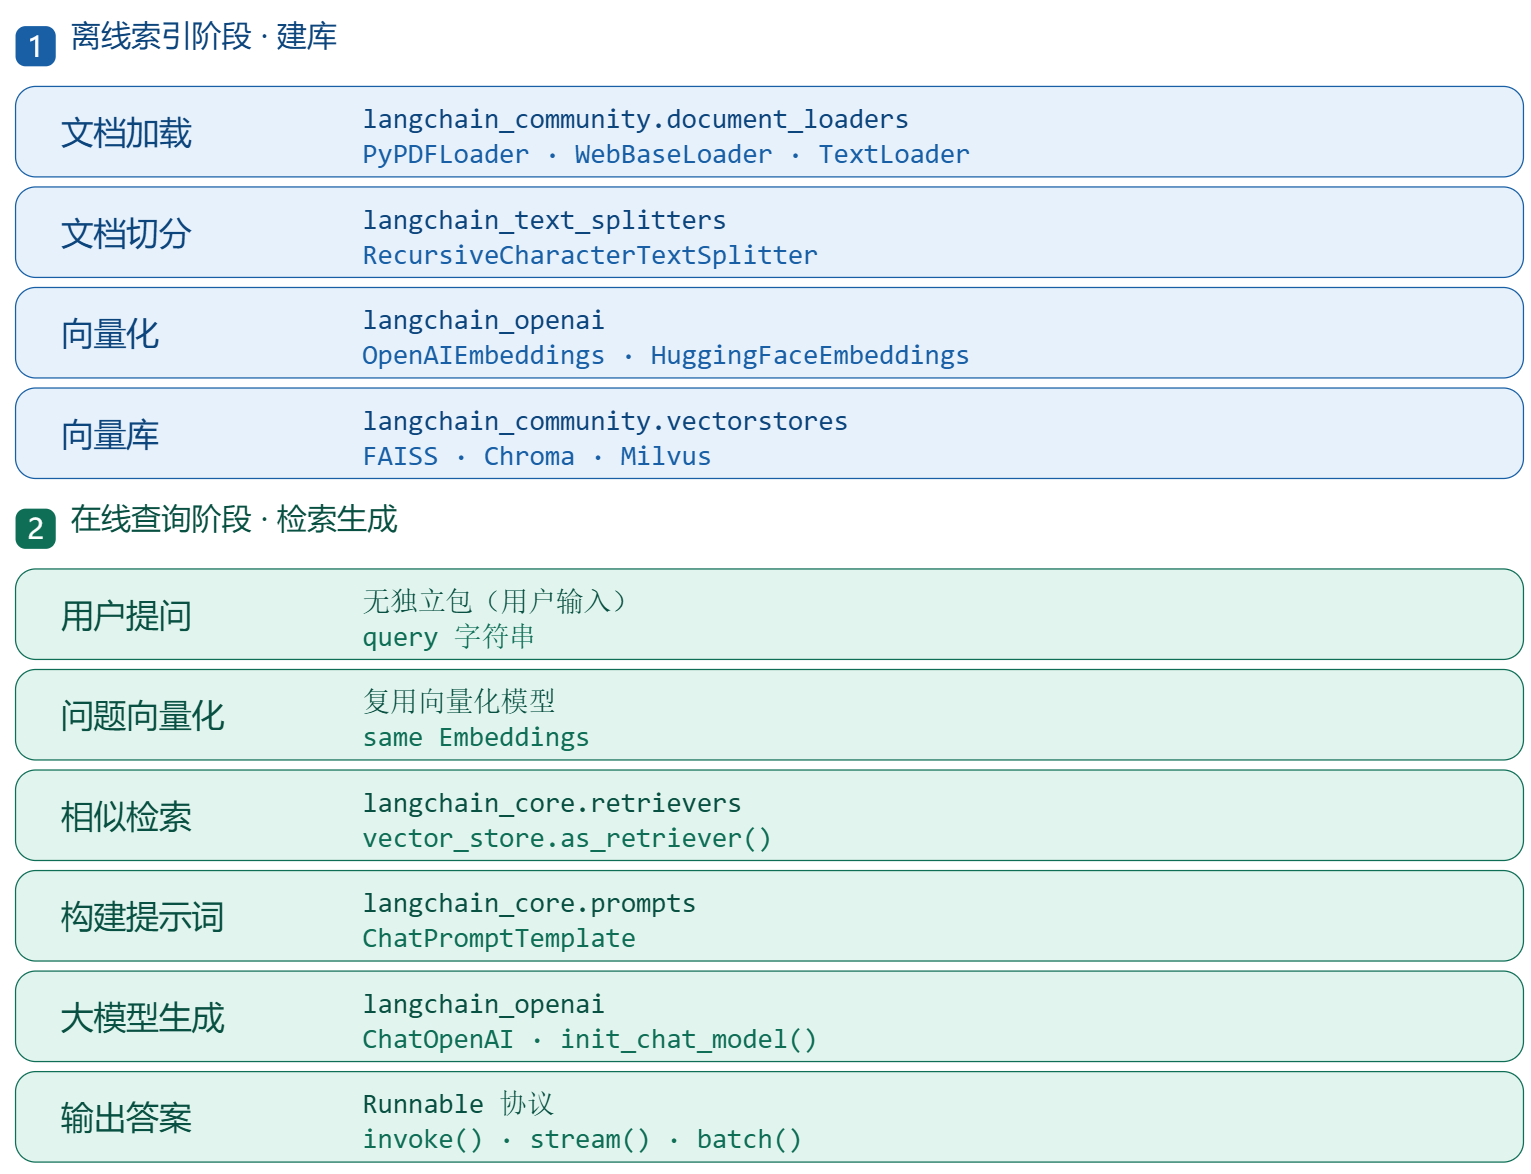

## 一、离线索引阶段

### 1. 文档加载

#### 1.1 Document

`Document` 是 LangChain 里最核心的数据结构，所有文档在加载后都会统一成这个对象。先看它的结构：

| 字段 | 类型 | 是否必填 | 作用 |
|------|------|---------|------|
| `page_content` | `str` | ✅ 必填 | 文档正文文本，真正要向量化、喂给大模型的内容 |
| `metadata` | `dict` | 可选（默认 `{}`） | 来源、页码等附加信息，不进向量，只用于溯源/过滤 |
| `id` | `str \| None` | 可选 | 唯一标识（新版新增，用于去重、追踪） |
| `type` | `str` | 可选（默认 `"Document"`） | 多态序列化时标记类型 |

> **关键理解**：`page_content` 决定「查什么」，`metadata` 决定「从哪来、怎么过滤」。


In [2]:
from langchain_core.documents import Document   # ① 导入 Document 类

doc = Document(                                  # ② 实例化一个文档对象
    page_content="LangChain 是一个用于构建大模型应用的框架。",
    metadata={"source": "docs/langchain.pdf", "page": 3, "title": "LangChain 入门"},
)

print(doc.page_content)        # ③ 取出正文
print(doc.metadata)            # ④ 取出元数据
print(doc.metadata["source"])  # ⑤ 按 key 取具体值：docs/langchain.pdf

LangChain 是一个用于构建大模型应用的框架。
{'source': 'docs/langchain.pdf', 'page': 3, 'title': 'LangChain 入门'}
docs/langchain.pdf


### 1.2 Docx2txtLoader

```
TXT文档:TextLoader
PDF文档:PyPDFLoader
CSV文档:CSVLoader
JSON文档:JSONLoader
HTML文档:UnstructuredHTMLLoader
MD文档:UnStructuredMarkdownLoader
文件目录:DirectoryLoader

```

```
加载word文档 安装 pip install docx2txt
加载json文档 安装 pip install jq
加载pdf文档  安装 pip install pymupdf
加载HTML文档 安装 pip install unstructured
加载MD文档   安装 pip install markdown +  pip install unstructured
```

In [3]:
from langchain_community.document_loaders import UnstructuredWordDocumentLoader, Docx2txtLoader

# 1.指定要加载的Word文档路径
loader = Docx2txtLoader("./data/人事管理流程.docx")
# 加载文档、转换格式化成 List[Document]
documents = loader.load()

C:\Users\user\AppData\Local\Temp\ipykernel_2320\2112309896.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import UnstructuredWordDocumentLoader, Docx2txtLoader


In [4]:
print(type(documents))
print(len(documents))
# print(documents[0].page_content)  # 文件内容
print(documents[0].metadata)        # 文件元数据

<class 'list'>
1
{'source': './data/人事管理流程.docx'}


In [5]:
for key in documents[0].model_dump(): # 转换成字典
    print(key)

id
metadata
page_content
type


## 2. 文档切割

#### 2.1 递归切割

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# separators
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, #切块大小
    chunk_overlap=50,  # 切块重叠大小
    # separators=[".", '\n', '!', '?', ';'] # 分隔符优先级列表
)
# 通过分割器获取document :create_documents   split_documents  传入一个document对象，返回一个document对象列表
split_documents = text_splitter.split_documents(documents)

In [7]:
print(len(split_documents))

16


**内置分割器：** https://reference.langchain.com/python/langchain-text-splitters

### 3. 向量化

#### 3.1 阿里通义千问嵌入模型

`pip install dashscope`

In [8]:
# 模型包装器：大模型分成三类：LLM  聊天模型  嵌入模型
# 获得一个阿里通义千问嵌入模型的实例，同样在models.py中被包装为get_ali_embeddings()
import os
from langchain_community.embeddings import DashScopeEmbeddings
# 嵌入模型的模型包装器
llm_embeddings = DashScopeEmbeddings(
    model="text-embedding-v3", # 模型名称
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY") # API_KEY
)

### 4. 向量存储

#### 4.1 Chroma

`pip install chromadb`

In [13]:
from langchain_community.vectorstores import Chroma
# 实例化向量空间，向量化+向量存储到向量数据库中
vector_store = Chroma.from_documents(
    documents=split_documents,
    embedding=llm_embeddings,
    # persist_directory="./chroma_db",  # 持久化目录
    # collection_metadata={"hnsw:space": "cosine"} # 改成余弦相似度
)

In [40]:
# 按相似度的分数进行排序，分数值越小，越相似（其实是L2距离）
docs = vector_store.similarity_search("晋升", k=3) # 默认 k = 4 	List[Document]（纯文档列表）
for doc in docs:
    print(doc.page_content[:10])

print("--"*80)
results = vector_store.similarity_search_with_score("晋升", k=3) # List[Tuple[Document, float]]（文档+分数元组）
for doc, score in results:
    print(score, "|", doc.page_content[:10])

2.9月度连续旷工3
2.9月度连续旷工3
员工申请    主管
----------------------------------------------------------------------------------------------------------------------------------------------------------------
0.7932792901992798 | 2.9月度连续旷工3
0.7932792901992798 | 2.9月度连续旷工3
0.9132716059684753 | 员工申请    主管


> "Chroma 是 LangChain 封装的开源向量数据库，核心能力是把文本向量化后存储，并提供语义检索。建库用 `from_documents`（已切分文档）或 `from_texts`（纯文本）；检索有三个变体——`similarity_search` 只返回文档、`similarity_search_with_score` 额外返回距离（越小越相似，用于调试和设阈值）、`similarity_search_with_relevance_scores` 返回 0~1 相关度（越大越像）。此外还有 `add_documents` 增量写入、`as_retriever` 转检索器对接 RAG 链、`max_marginal_relevance_search` 做多样化检索。最常见的坑是把 `with_score` 的分数当成相似度，其实它是距离。"
> - 「向量是怎么来的」 → 由 embedding 参数（如 OpenAIEmbeddings）把文本编码成高维向量，检索时同样把 query 编码后算相似度。
> - 「默认算的是哪种距离」 → Chroma 默认 L2 欧氏距离；可在建库时通过 collection_metadata={"hnsw:space": "cosine"} 改成余弦。
> - 「和 FAISS 有啥区别」 → 都是向量库，Chroma 自带持久化和元数据过滤、上手简单；FAISS 检索更快、适合超大规模，但需自己管理持久化。
> - 「什么是多样性检索（MMR）」 → MMR（最大边际相关性）是一种「既要相关、又要不重复」的检索策略：普通相似度检索只会返回和问题最像的 Top-K 条，但这些结果可能内容高度雷同，而 MMR 会先从知识库中检索一些候选文档集（fetch_k 个），再候选文档集中迭代挑选文档，每选一条都同时权衡「它跟问题够不够相关」和「它跟已选结果是否太像」（由 lambda_mult 控制偏向），最终返回既命中问题又彼此差异化的结果。​应用场景主要有三个（摘要任务，问答系统，推荐系统）：① 知识库里同一主题存在多篇重复/转载文章时，希望返回不同角度的内容；② 检索结果要喂给大模型做问答，避免重复内容占用上下文、浪费 token；③ 搜索引擎或推荐系统里做「结果去重 + 多样化展示」的召回

## 二、检索生成阶段

### 1. 检索
检索器 (Retriever) 是 RAG (检索增强生成) 系统的核心组件，负责从知识库中`查找与用户查询相关的文档片段`
```
# 1.创建 FAISS 检索器
retriever_faiss = FAISS.from_texts(texts, embeddings).as_retriever()
# 2.创建 Chroma 检索器
retriever_chroma = Chroma.from_documents(docs, embeddings).as_retriever()
# 3.关键词检索器
retriever_bm25 = BM25Retriever.from_texts(texts)
# 4.混合检索器 (结合语义+关键词)
ensemble_retriever = EnsembleRetriever(
    retrievers=[retriever_faiss, retriever_bm25],
    weights=[0.7, 0.3]  # 权重分配

```

In [10]:
# 检索器
retriever = vector_store.as_retriever()

# retriever = vector_store.as_retriever(
#     search_type="similarity_score_threshold",
#     search_kwargs={
#         "score_threshold": 0.3,
#     }
# )

# 检索器对象：检索文档，可以根据需要对检索后的结果做各种处理
# VectorStoreRetriever 中 allowed_search_types 参数设置检索方式：
# "similarity", 默认，向量相似度检索
# "similarity_score_threshold", 向量相似度阈值检索
# "mmr"  max margin relevance :一种平衡相关性和多样性的检索方式

In [11]:
print(type(retriever))

<class 'langchain_core.vectorstores.base.VectorStoreRetriever'>


In [45]:
retriever.invoke("晋升")  # List[Document]，检索结果是文档列表

[Document(metadata={'source': './data/人事管理流程.docx'}, page_content='2.9月度连续旷工3天者，或年度累计旷工2次；\n\n2.10法律法规或公司规章制度规定的其他情形。\n\n四、晋升\n\n\t  1、员工的晋升必须符合公司的需要，实行德能与业绩并重的原则；\n\n\t2、能升能降原则：根据绩效考核与综合能力考核，员工职位能者居之；\n\n\t3、晋升的流程：同试用与转正流程\n\n五、降级\n\n\t1、降级条件：经考核不能胜任工作\n\n\t2、降级流程：部门负责人与相关人员谈话     相关人员填写《员工降级审批表》    同试用与转正流程\n\n六、调岗\n\n   员工填写员工内部调动申请表    调出部门审批    用人部门\n\n审批   人事招聘主管审批    抄送人事经理/人事主管\n\n\t\t员工填写员工内部调动申请表（管理岗）    调出部门审批    用人部门审批   人事行政经理审批    总经理审批    抄送人事招聘/行政主管\n\n注：严禁私自调岗，申请审批通过后方可调职；\n\n七、离职  \n\n离职流程：递交《员工离职申请表》    主管部门审批    人事行政部审批    总经理审批    到期办理离职手续解除劳动合同停用账号与保险    财务核算工资    离职'),
 Document(metadata={'source': './data/人事管理流程.docx'}, page_content='2.9月度连续旷工3天者，或年度累计旷工2次；\n\n2.10法律法规或公司规章制度规定的其他情形。\n\n四、晋升\n\n\t  1、员工的晋升必须符合公司的需要，实行德能与业绩并重的原则；\n\n\t2、能升能降原则：根据绩效考核与综合能力考核，员工职位能者居之；\n\n\t3、晋升的流程：同试用与转正流程\n\n五、降级\n\n\t1、降级条件：经考核不能胜任工作\n\n\t2、降级流程：部门负责人与相关人员谈话     相关人员填写《员工降级审批表》    同试用与转正流程\n\n六、调岗\n\n   员工填写员工内部调动申请表    调出部门审批    用人部门\n\n审批   人事招聘主管审批    抄送人事经理/人事主管\n\n\t\t员工填写员

### 2. 生成

In [43]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

prompt_template = ChatPromptTemplate.from_messages([('human',"仅使用提供的上下文回答下面的问题：{question} 上下文： {context}")])
model = init_chat_model(model="deepseek-flash")

# 定义这个链的时候，还不知道问题是什么，
# 用RunnablePassthrough允许我们将用户的具体问题在实际使用过程中进行动态传入
chain = {"question":RunnablePassthrough(), "context": retriever} | prompt_template | model

#用大模型生成答案
resp = chain.invoke("晋升")
print(resp.content)

根据提供的上下文，关于“晋升”的规定如下：

1. 员工的晋升必须符合公司的需要，实行德能与业绩并重的原则；
2. 能升能降原则：根据绩效考核与综合能力考核，员工职位能者居之；
3. 晋升的流程：同试用与转正流程。


> 拆解：invoke("晋升") 时，RunnablePassthrough() 把 "晋升" 原样填进 question，retriever 同时去查库填 context → 两者拼成字典喂给模板 → 生成完整 Prompt → 交给 client 生成 → 返回 AIMessage，用 .content 取文本

In [61]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate


prompt_template = ChatPromptTemplate.from_messages([('human',"仅使用提供的上下文回答下面的问题：{input} 上下文： {context}")])
model = init_chat_model(model="deepseek-flash")

# create_stuff_documents_chain(llm, prompt): 生成"文档→答案"这一段；内部把 {context} 里的多个 Document 转成字符串、拼进 prompt 槽位，再交给 llm
chain1 = create_stuff_documents_chain(model, prompt_template)
# create_retrieval_chain(retriever, document_chain): 把"检索"和"文档链"串起来；invoke 时先 retriever.invoke(input) 召回文档，再作为 context 喂给上面的链
chain2 = create_retrieval_chain(retriever,chain1)

#用大模型生成答案
result = chain2.invoke({"input":"晋升"})
print(result["answer"])

根据提供的上下文，关于“晋升”的内容如下：

1. 员工的晋升必须符合公司的需要，实行德能与业绩并重的原则。
2. 能升能降原则：根据绩效考核与综合能力考核，员工职位能者居之。
3. 晋升的流程：同试用与转正流程。


In [60]:
print(type(result))
for key in resp:
    print(key)

# result["answer"] # 	模型最终回答
# result["context"] # 召回原始文档 → 答案溯源（RAG 面试高频考点）

<class 'dict'>
input
context
answer
